# **Part #5**

In [ ]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Import original Olist data file from HW2 with features for model training

olist_orders_features = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATA 6545 Data Science and MLOps/Data Files/HW3/Olist_Orders_Model_Dataset.csv')
olist_orders_features = olist_orders_features.drop(columns=['Unnamed: 0'])
olist_orders_features.head()

,delivery_days,delivery_vs_estimated,price,freight_ratio,product_category,customer_state,seller_state,payment_type,distance_miles,product_volume_cm^3,total_order_value,is_positive_review
0,8.0,-8.0,29.99,0.290764,housewares,SP,SP,credit_card,11.513378,1976.0,89.97,1
1,8.0,-8.0,29.99,0.290764,housewares,SP,SP,voucher,11.513378,1976.0,89.97,1
2,8.0,-8.0,29.99,0.290764,housewares,SP,SP,voucher,11.513378,1976.0,89.97,1
3,13.0,-6.0,118.70,0.191744,perfumery,BA,SP,boleto,525.344592,4693.0,118.70,1
4,9.0,-18.0,159.90,0.120200,auto,GO,SP,credit_card,318.202316,9576.0,159.90,1


In [ ]:
# Original model from HW2:

# Train/Test Split:
from sklearn.model_selection import train_test_split

X = olist_orders_features.drop(columns=['is_positive_review'])
y = olist_orders_features['is_positive_review']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Train balance: {y_train.mean():.1%} positive')
print(f'Test balance: {y_test.mean():.1%} positive')

X_train shape: (90807, 11)
X_test shape: (22702, 11)
Train balance: 76.2% positive
Test balance: 76.2% positive


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_balanced = Pipeline([('preprocessor', preprocessor), ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))])

random_forest_balanced.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['delivery_days',
                                                   'delivery_vs_estimated',
                                                   'price', 'freight_ratio',
                                                   'distance_miles',
                                                   'product_volume_cm^3',
                                                   'total_order_value']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['product_category',
                                                   'customer_state',
                                                   'seller_state',
                                                   'payment_type'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [ ]:
# Model Evaluation

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

y_pred = random_forest_balanced.predict(X_test)
y_prob = random_forest_balanced.predict_proba(X_test)[:, 1]

accuracy_HW2 = accuracy_score(y_test, y_pred)
precision_HW2 = precision_score(y_test, y_pred)
recall_HW2 = recall_score(y_test, y_pred)
f1_score_HW2 = f1_score(y_test, y_pred)
roc_auc_score_HW2 = roc_auc_score(y_test, y_prob)

print(f'Accuracy: {accuracy_HW2:.1%}')
print(f'Precision: {precision_HW2:.1%}')
print(f'Recall: {recall_HW2:.1%}')
print(f'f1 score: {f1_score_HW2:.1%}')
print(f'ROC-AUC score: {roc_auc_score_HW2:.1%}')

Accuracy: 85.3%
Precision: 85.0%
Recall: 98.1%
f1 score: 91.1%
ROC-AUC score: 80.2%


In [ ]:
# Generating six months of drift data

import numpy as np

monthly_data = []

for month in range(1, 7):
    sample = olist_orders_features.sample(n=3000, replace=True).copy()
    sample["month"] = month

    # Months 1–3: small noise
    if month <= 3:
        for col in ["delivery_days", "freight_ratio", "price"]:
            sample[col] = sample[col] * (1 + np.random.uniform(-0.05, 0.05, size=len(sample)))

    # Months 4–6: drift
    if month == 4:
        sample["delivery_days"] += 2
        sample["freight_ratio"] *= 1.15
        sample.loc[sample.sample(frac=0.10).index, "product_category"] = "electronics"

    elif month == 5:
        sample["delivery_days"] += 4
        sample["freight_ratio"] *= 1.30
        sample.loc[sample.sample(frac=0.15).index, "product_category"] = "electronics"

    elif month == 6:
        sample["delivery_days"] += 6
        sample["freight_ratio"] *= 1.50
        sample.loc[sample.sample(frac=0.20).index, "product_category"] = "electronics"

    # Label flipping
    if month >= 4:
        flip_idx = sample[sample["is_positive_review"] == 1].sample(frac=0.05).index
        sample.loc[flip_idx, "is_positive_review"] = 0

    monthly_data.append(sample)

prod_data = pd.concat(monthly_data, ignore_index=True)

In [ ]:
# Drift detection

reference = olist_orders_features.copy()

# PSI Calculation

def calculate_psi(expected, actual, bins=10):
    expected_percents, bin_edges = np.histogram(expected, bins=bins)
    actual_percents, _ = np.histogram(actual, bins=bin_edges)

    expected_percents = expected_percents / len(expected)
    actual_percents = actual_percents / len(actual)

    # Avoid division by zero
    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)

    psi = np.sum((actual_percents - expected_percents) *
                 np.log(actual_percents / expected_percents))
    return psi

In [ ]:
# PSI per month

features = ["delivery_days", "freight_ratio", "price"]

psi_results = pd.DataFrame(index=features, columns=range(1, 7))

for month in range(1, 7):
    month_data = prod_data[prod_data["month"] == month]

    for feature in features:
        psi = calculate_psi(reference[feature], month_data[feature])
        psi_results.loc[feature, month] = psi

psi_results = psi_results.astype(float)
print(psi_results)

                      1         2         3         4         5         6
delivery_days  0.000723  0.003268  0.000930  0.006805  0.059517  0.117842
freight_ratio  0.001214  0.001456  0.000552  0.002428  0.001896  0.005706
price          0.000597  0.005141  0.002525  0.003652  0.001300  0.002237


In [ ]:
# Interpretation

def psi_flag(x):
    if x < 0.1:
        return "No Drift"
    elif x < 0.2:
        return "Moderate"
    else:
        return "Significant"

psi_flags = psi_results.map(psi_flag)
psi_flags

,1,2,3,4,5,6
delivery_days,No Drift,No Drift,No Drift,No Drift,No Drift,Moderate
freight_ratio,No Drift,No Drift,No Drift,No Drift,No Drift,No Drift
price,No Drift,No Drift,No Drift,No Drift,No Drift,No Drift


In [ ]:
# KS Test

from scipy.stats import ks_2samp

ks_results = pd.DataFrame(index=features, columns=range(1, 7))

for month in range(1, 7):
    month_data = prod_data[prod_data["month"] == month]

    for feature in features:
        stat, p_value = ks_2samp(reference[feature], month_data[feature])
        ks_results.loc[feature, month] = p_value

ks_results = ks_results.astype(float)
print(ks_results)

ks_flags = ks_results.map(lambda x: "Significant" if x < 0.05 else "No Drift")
print(ks_flags)

                      1             2         3             4              5  \
delivery_days  0.000092  2.292475e-09  0.000011  2.865694e-62  1.020016e-212   
freight_ratio  0.987535  3.682416e-01  0.920420  1.559027e-13   6.339418e-61   
price          0.027247  5.101576e-06  0.097936  3.398618e-01   2.488892e-01   

                           6  
delivery_days   0.000000e+00  
freight_ratio  5.766705e-106  
price           9.968951e-01  
                         1            2            3            4  \
delivery_days  Significant  Significant  Significant  Significant   
freight_ratio     No Drift     No Drift     No Drift  Significant   
price          Significant  Significant     No Drift     No Drift   

                         5            6  
delivery_days  Significant  Significant  
freight_ratio  Significant  Significant  
price             No Drift     No Drift  


In [ ]:
# Predict production data using HW2 model

X_test_prod = prod_data.drop(columns=["is_positive_review", "month"])
y_test_prod = prod_data["is_positive_review"]

y_pred = random_forest_balanced.predict(X_test_prod)
y_prob = random_forest_balanced.predict_proba(X_test_prod)[:, 1]

prod_data["y_pred"] = y_pred
prod_data["y_prob"] = y_prob

metrics = []

for month in range(1, 7):
    df_m = prod_data[prod_data["month"] == month]

    acc = accuracy_score(df_m["is_positive_review"], df_m["y_pred"])
    f1 = f1_score(df_m["is_positive_review"], df_m["y_pred"])
    auc = roc_auc_score(df_m["is_positive_review"], df_m["y_prob"])

    metrics.append({
        "month": month,
        "accuracy": acc,
        "f1": f1,
        "auc": auc
    })

metrics_df = pd.DataFrame(metrics)
print(metrics_df)

   month  accuracy        f1       auc
0      1  0.961000  0.975363  0.979080
1      2  0.960667  0.974403  0.980211
2      3  0.957667  0.972373  0.978008
3      4  0.863000  0.912348  0.904496
4      5  0.824000  0.890137  0.855319
5      6  0.807333  0.880874  0.831551


In [ ]:
# Performance drop (from month 1 to 6)

m1 = metrics_df[metrics_df["month"] == 1].iloc[0]
m6 = metrics_df[metrics_df["month"] == 6].iloc[0]

f1_drop_abs = m6["f1"] - m1["f1"]
f1_drop_pct = (f1_drop_abs / m1["f1"]) * 100

print(f"F1 drop: {f1_drop_abs:.4f} ({f1_drop_pct:.2f}%)")

F1 drop: -0.0945 (-9.69%)


In [ ]:
# Design dataframe for alert summary

psi_long = psi_results.reset_index().melt(
    id_vars="index",
    var_name="month",
    value_name="psi"
)

psi_long = psi_long.rename(columns={"index": "feature"})

def severity(x):
    if x < 0.1:
        return "No Drift"
    elif x < 0.2:
        return "Moderate Drift"
    else:
        return "Significant Drift"

psi_long["severity"] = psi_long["psi"].apply(severity)

def action(row):
    if row["psi"] >= 0.2:
        return "Retrain model"
    elif row["psi"] >= 0.1:
        return "Investigate feature"
    else:
        return "No action"

psi_long["action"] = psi_long.apply(action, axis=1)

alerts_df = psi_long.sort_values(["month", "psi"], ascending=[True, False])
alerts_df

,feature,month,psi,severity,action
1,freight_ratio,1,0.001214,No Drift,No action
0,delivery_days,1,0.000723,No Drift,No action
2,price,1,0.000597,No Drift,No action
5,price,2,0.005141,No Drift,No action
3,delivery_days,2,0.003268,No Drift,No action
4,freight_ratio,2,0.001456,No Drift,No action
8,price,3,0.002525,No Drift,No action
6,delivery_days,3,0.000930,No Drift,No action
7,freight_ratio,3,0.000552,No Drift,No action
9,delivery_days,4,0.006805,No Drift,No action


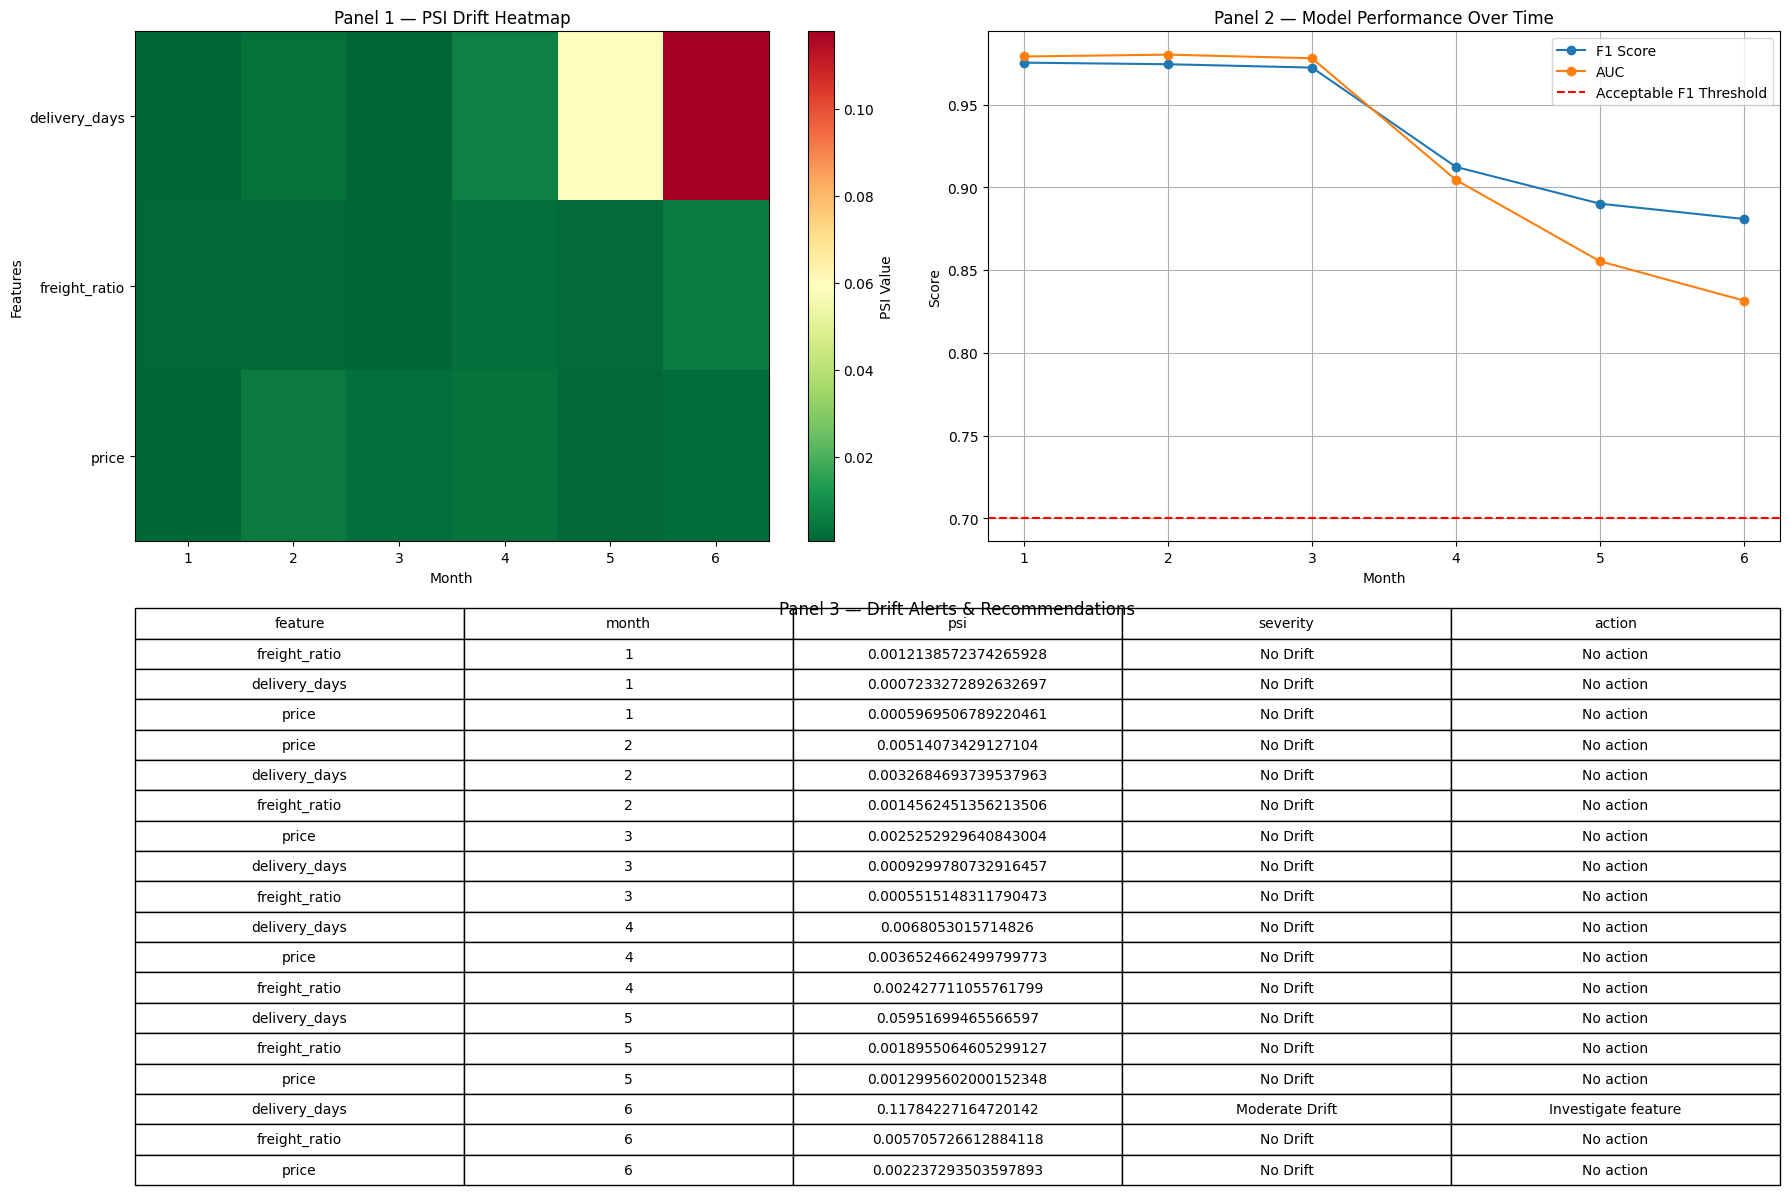

In [ ]:
# Performance dashboard

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(18, 12))


# Panel 1 — PSI Heatmap

ax1 = plt.subplot(2, 2, 1)

im = ax1.imshow(psi_results.values, aspect='auto', cmap='RdYlGn_r')

# Labels
ax1.set_xticks(np.arange(len(psi_results.columns)))
ax1.set_xticklabels(psi_results.columns)
ax1.set_yticks(np.arange(len(psi_results.index)))
ax1.set_yticklabels(psi_results.index)

ax1.set_title("Panel 1 — PSI Drift Heatmap")
ax1.set_xlabel("Month")
ax1.set_ylabel("Features")

# Colorbar
cbar = plt.colorbar(im, ax=ax1)
cbar.set_label("PSI Value")


# Panel 2 — Performance Trend

ax2 = plt.subplot(2, 2, 2)

ax2.plot(metrics_df["month"], metrics_df["f1"], marker='o', label="F1 Score")
ax2.plot(metrics_df["month"], metrics_df["auc"], marker='o', label="AUC")

# Threshold line
threshold = 0.70
ax2.axhline(y=threshold, linestyle='--', color='red', label="Acceptable F1 Threshold")

ax2.set_title("Panel 2 — Model Performance Over Time")
ax2.set_xlabel("Month")
ax2.set_ylabel("Score")
ax2.set_xticks(metrics_df["month"])
ax2.legend()
ax2.grid(True)


# Panel 3 — Alert Summary Table

ax3 = plt.subplot(2, 1, 2)
ax3.axis('off')

# Build table content
table_data = alerts_df.values
columns = alerts_df.columns

table = ax3.table(
    cellText=table_data,
    colLabels=columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

ax3.set_title("Panel 3 — Drift Alerts & Recommendations", pad=20)

plt.tight_layout()
plt.show()

# **Recommendations:**

Based on this analysis of 6 months worth of simulated drift, the model does not appear in need of retraining overall. Looking at the PSI calculated on the three variables in this demonstration, there is only one month on one variable where drift is apparent, and in all other cases the PSI values did not meet the threshold for being considered as drift. Looking at these same variables using KS Test, however, over half of the values for each variable and month are classified as drift, which stands in contrast to the measurement by PSI. Looking at model performance by PSI, the model performance is stable until month 4 where drift was introduced, and proceeds to decline linearly from there. F1 score and AUC drop from roughly 0.97 to 0.88 and 0.84 respectively from month 3 to month 6, with the F1 score remaining well above the acceptible threshold of 0.70. Based on this, the model does not need to be retrained after 6 months. If PSI were to consistently reach close to 0.1 for each variable at a given month and F1 score were to drop below this threshold, then it would be worth considering retraining the model.